# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [2]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])


nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [14]:
def plot_bins_diag(dfs, dfr, key_bins) : 
    # bins
    df = pd.concat([dfs, dfr[key_bins]], axis=1).dropna()
    quantile = np.array([0] + [df[key_bins].quantile(i) for i in np.linspace(1e-3, 1-1e-3, 30)]) # 15 = 10 000 par cut
    df[key_bins + '_cut']= pd.cut(df[key_bins], quantile, labels=(quantile[1:] + quantile[:-1])/2)
    ds = compute_mean_square_groupby(df, groupby = key_bins + '_cut')

    #plot pair's contributions
    Xn = [k for k in ds.keys() if 'Xn' in k]
    Xe = [k for k in ds.keys() if 'Xe' in k]
    xstyle = {l.replace('Xn_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in Xn}
    
    fig, axs = plt.subplots(1, 3, figsize=(15,6))
    axs =axs.flatten()
    for xn in Xn:
        ds[xn].plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
    for xe in Xe:
        ds[xe].plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
    i=0
    for xn in Xn:
        (ds[xn] +ds[Xe[i]]).plot( ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
        i+=1
        
    fig.tight_layout()
    for ax in axs:
        ax.grid()
        ax.set_ylabel(r'[$\gamma^2$]')
    axs[0].legend()
    
    axs[0].set_title('Zonal')
    axs[1].set_title('Meridional')
    axs[2].set_title('Total')
    
    axs[2].set_ylim(-5, 40)

    # plot residual vs balanced part contribution
    Bn = [k for k in ds.keys() if 'Bn' in k]
    Be = [k for k in ds.keys() if 'Be' in k]
    
    fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True, )
    axs =axs.flatten()
    i=0
    for be in Be:
        ax=axs[i]
        ds[be].plot(ax=ax, label=be, color = c0[be.replace('Be_', '')])
        ds[be.replace('Be_', 'Ee_')].plot(ax=ax,color = c0[be.replace('Be_', '')], ls='--')
        i+=1
        ax.set_title('Zonal balanced contribution ' + be.replace('Be_', ''))
    
    for bn in Bn:
        ax=axs[i]
        ds[bn].plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
        ds[bn.replace('Bn_', 'En_')].plot(ax=ax,color = c0[bn.replace('Bn_', '')], ls='--')
        i+=1
        ax.set_title('Meridional balanced contribution ' + bn.replace('Bn_', ''))
        
    for bn in Bn:
        ax=axs[i]
        (ds[bn] +ds[Be[i-8]]).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
        (ds[bn.replace('Bn_', 'En_')] +ds[Be[i-8].replace('Be_', 'Ee_')]).plot(ax=ax,color = c0[bn.replace('Bn_', '')], ls='--')
        i+=1
        ax.set_title('Total balanced contribution ' + bn.replace('Bn_', ''))
        
    fig.tight_layout()
    for ax in axs:
        ax.grid()
        ax.set_ylabel(r'[$\gamma^2$]')
    
    fig.tight_layout()

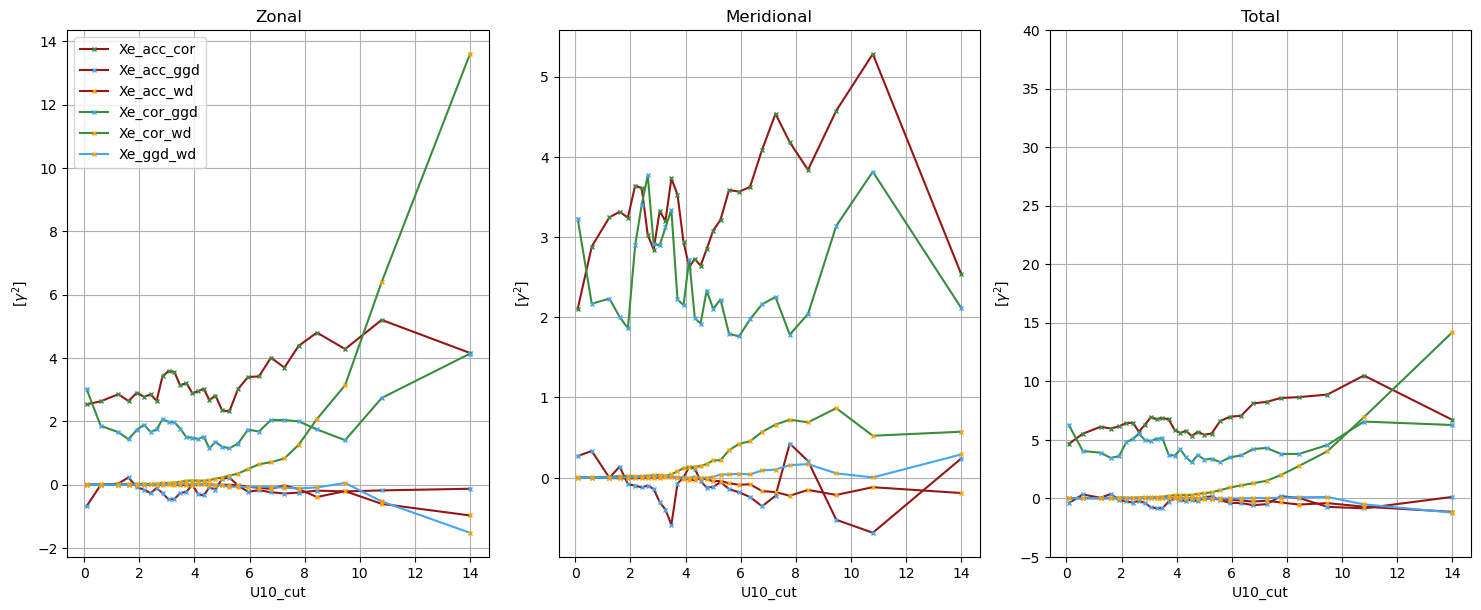

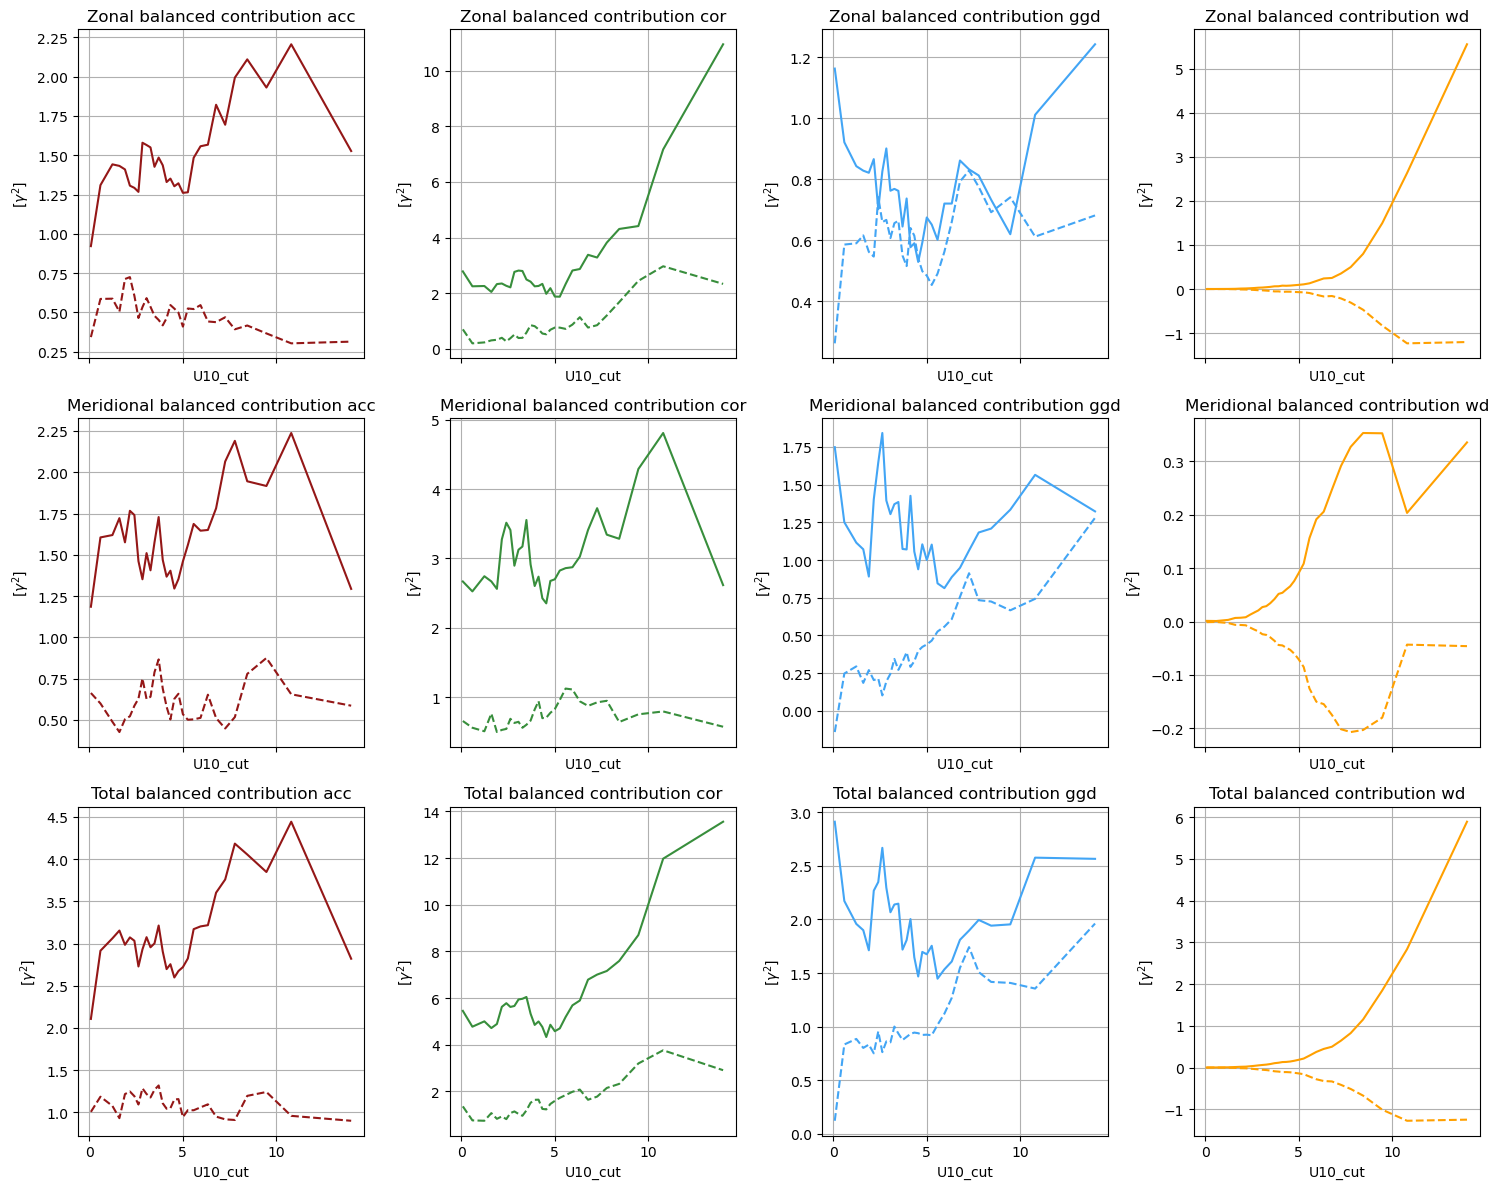

In [15]:
dfs = DSS.to_dataframe().reset_index().set_index('row_number')
dfs = dfs[(dfs.sume<1e-4) & (dfs.sumn<1e-4)]
dfw = pd.read_csv(WD['era5']).set_index('row_number')
dfw['U10'] = np.sqrt(dfw.u10**2 + dfw.v10**2)
plot_bins_diag(dfs, dfw, 'U10')

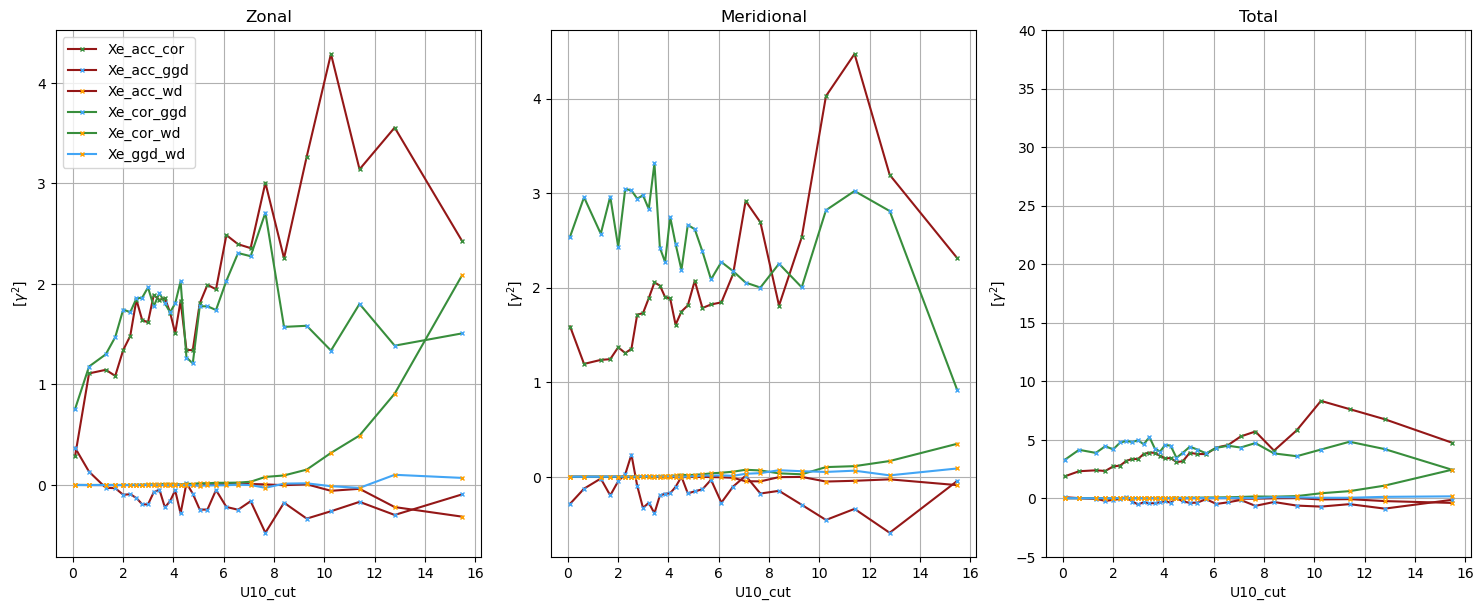

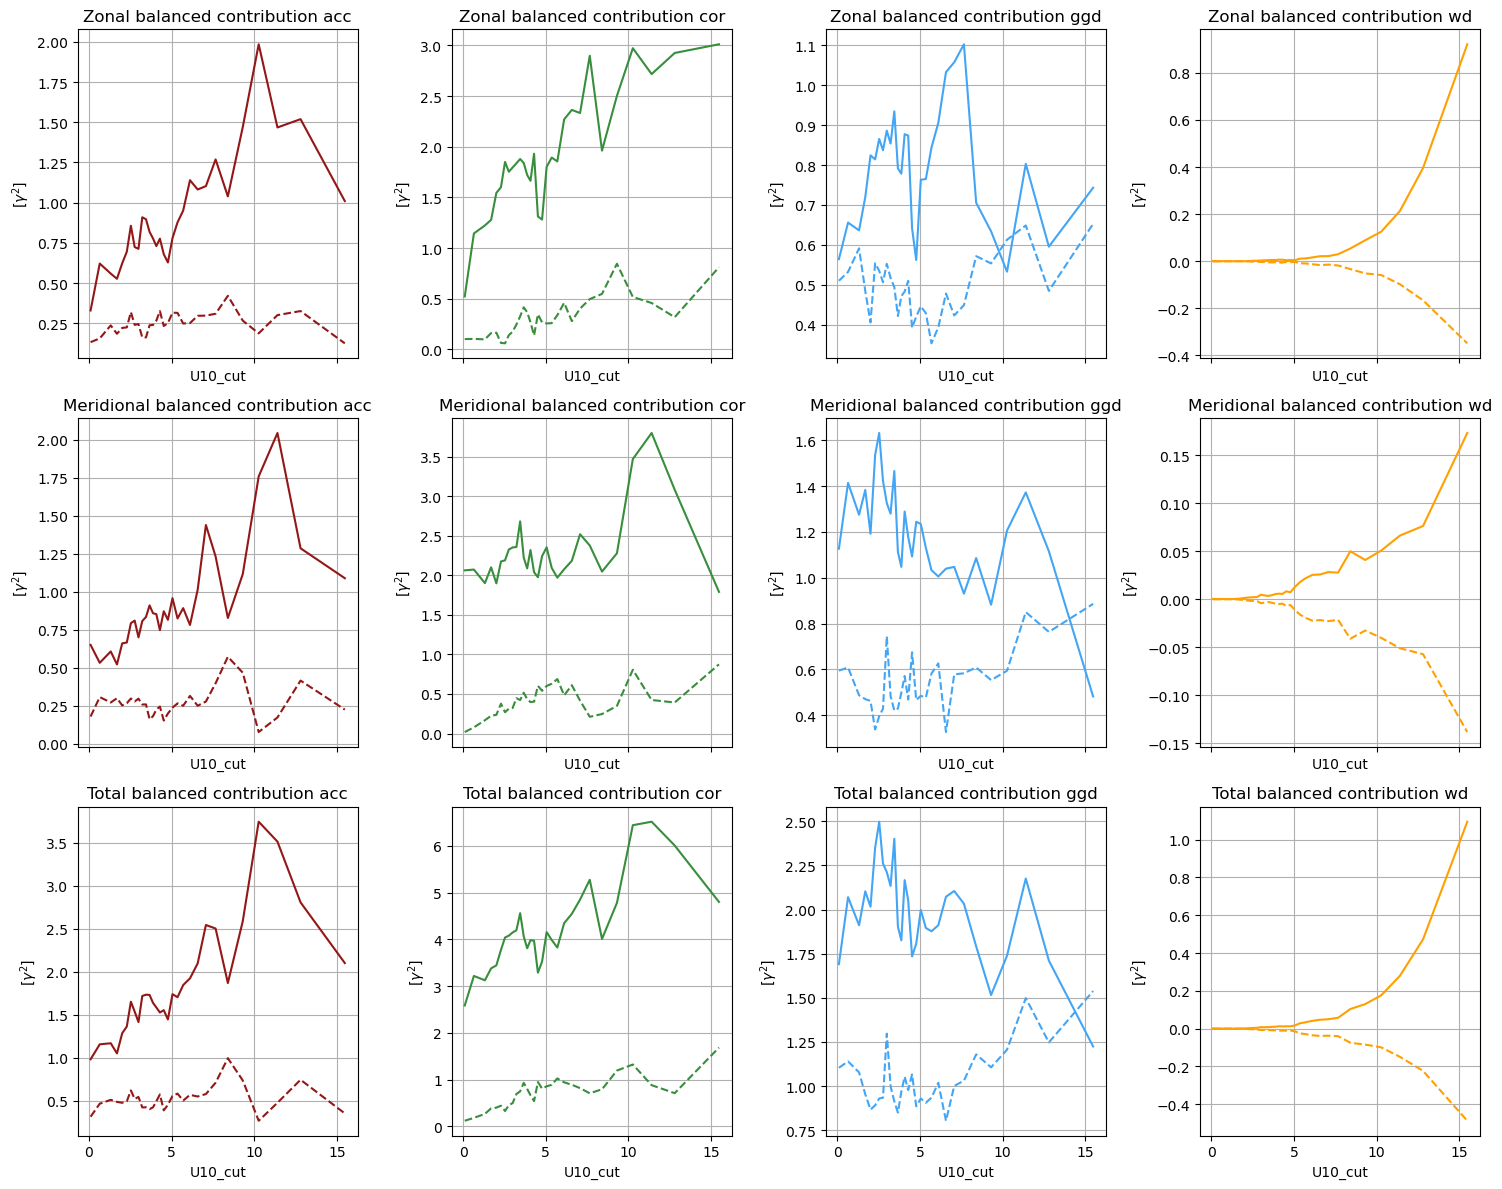

In [16]:
dfs = DSD.to_dataframe().reset_index().set_index('row_number')
dfs = dfs[(dfs.sume<1e-4) & (dfs.sumn<1e-4)]
dfw = pd.read_csv(WD['era5']).set_index('row_number')
dfw['U10'] = np.sqrt(dfw.u10**2 + dfw.v10**2)
plot_bins_diag(dfs, dfw, 'U10')